In [35]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pygraphviz as pgv
from nxpd import draw, nxpdParams
#from networkx.drawing.nx_agraph import graphviz_layout

nxpdParams['show'] = 'ipynb'
%matplotlib inline

# Global Measures

In [2]:
G = nx.erdos_renyi_graph(30, 0.11)

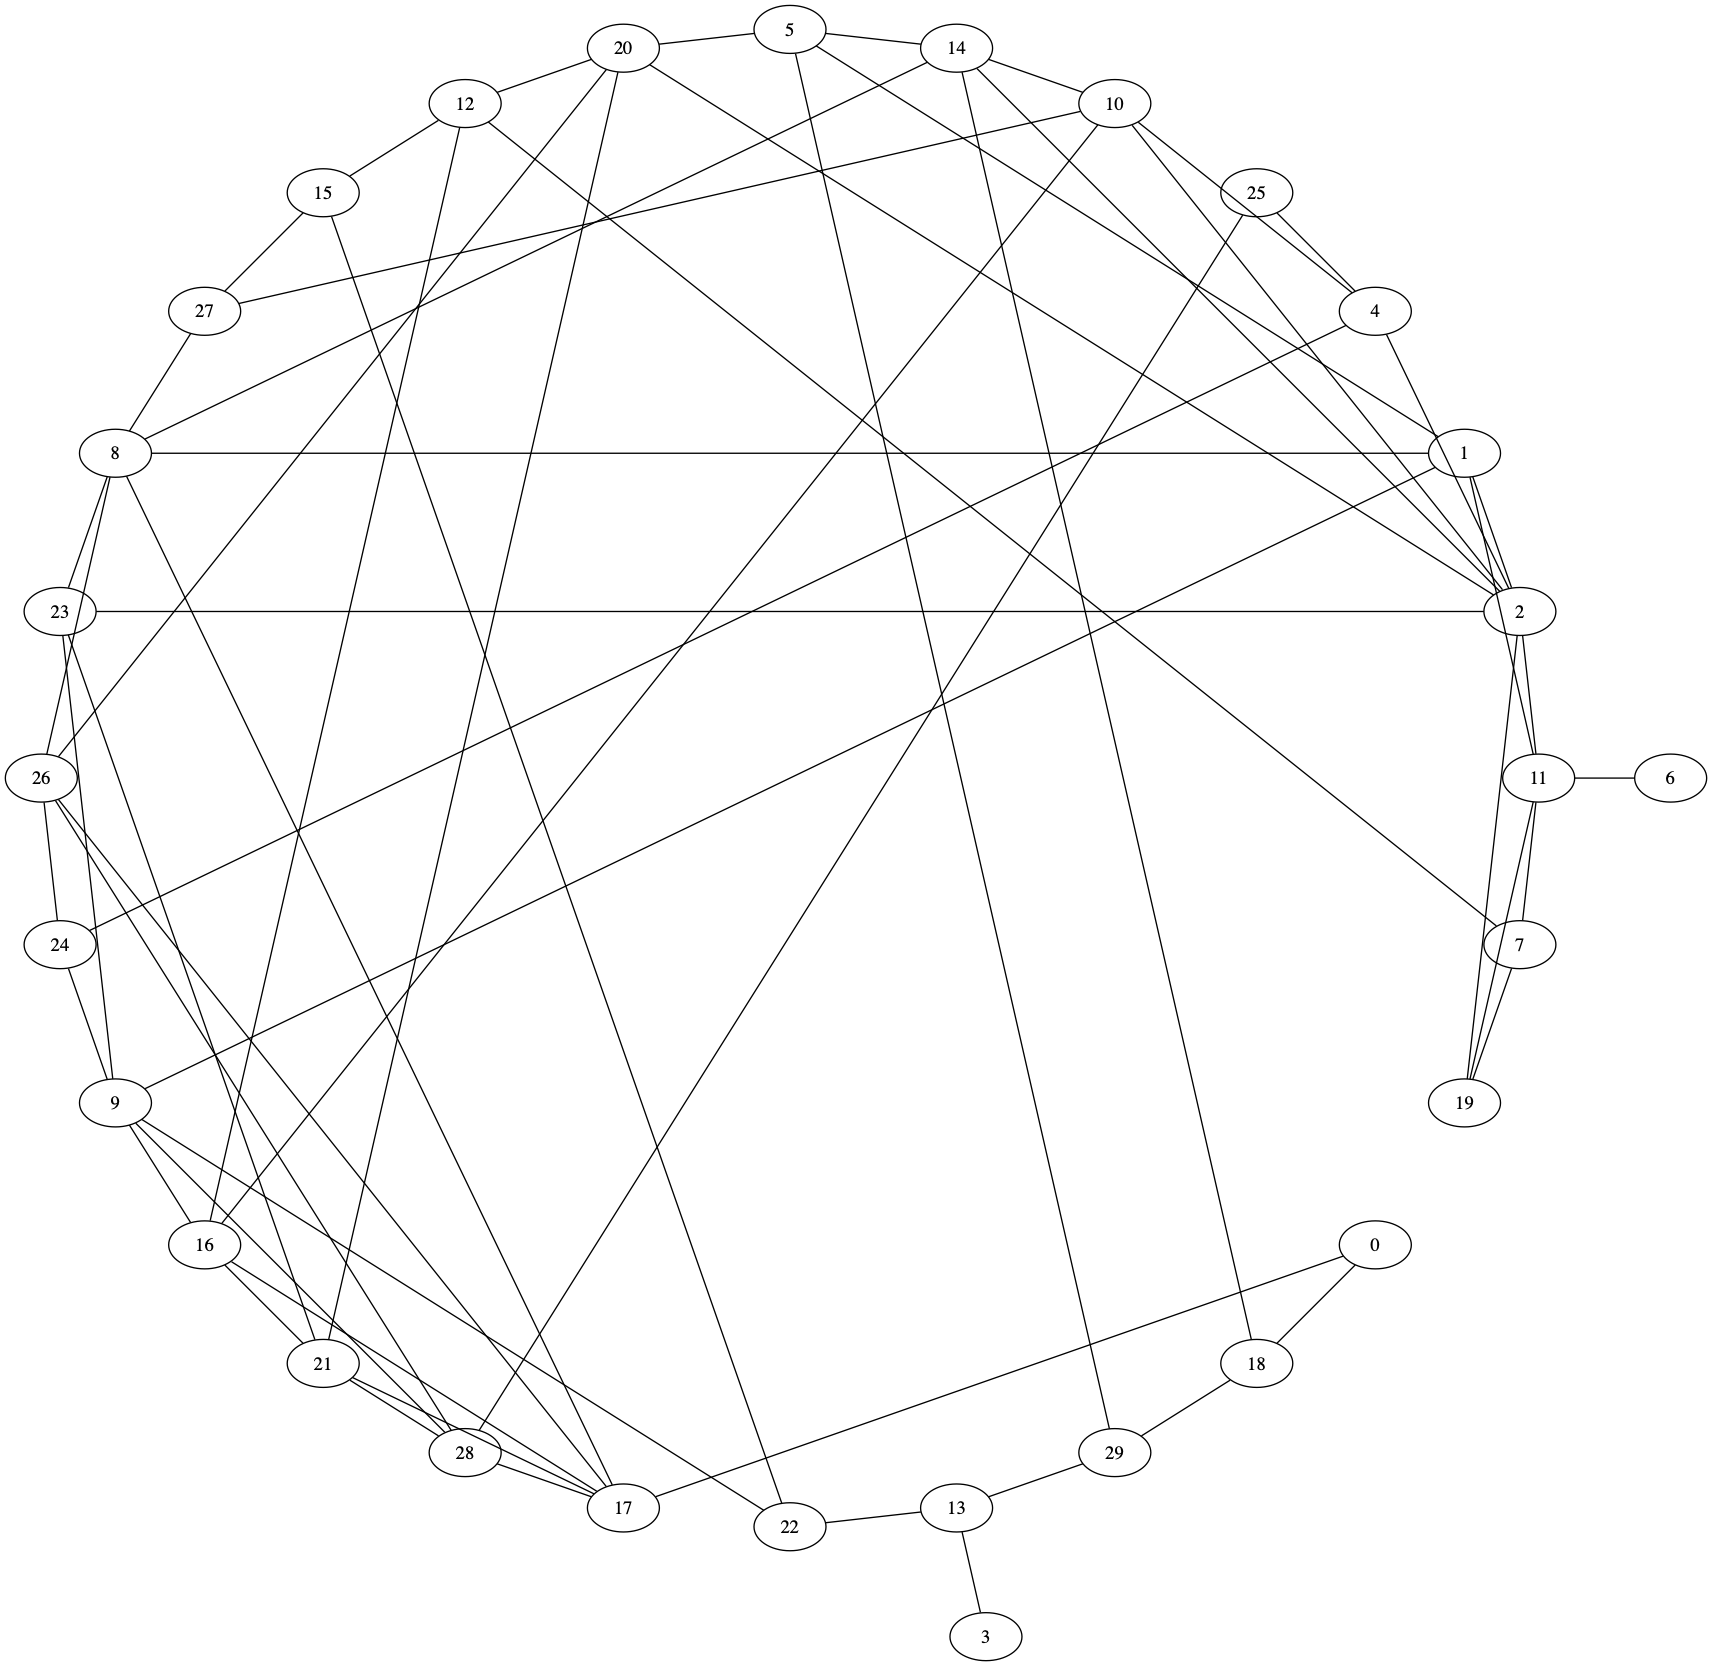

In [3]:
draw(G, layout='circo')

In [4]:
len(G)

30

In [5]:
len(G.nodes)

30

In [6]:
len(G.edges)

60

In [7]:
len(list(nx.non_edges(G)))

375

In [8]:
nx.density(G)

0.13793103448275862

In [9]:
ego = 21
alters1 = G[ego]
alters1

AtlasView({16: {}, 17: {}, 20: {}, 23: {}, 28: {}})

In [10]:
len(alters1)

5

In [11]:
alters2 = list(nx.all_neighbors(G, ego))
alters2

[16, 17, 20, 23, 28]

In [12]:
len(alters2)

5

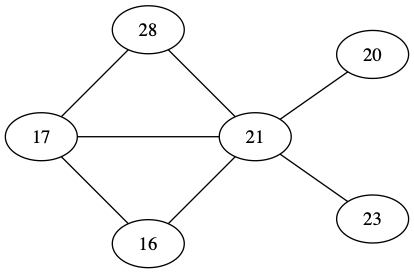

In [13]:
egonet = nx.ego_graph(G, ego)
draw(egonet, layout='circo')

In [14]:
clust_coef = nx.clustering(nx.Graph(G), ego)
clust_coef
# clustering here is a measure of "stariness"

0.2

In [15]:
avg_cc = nx.average_clustering(nx.Graph(G))
avg_cc

0.10142857142857145

In [16]:
trans = nx.transitivity(G)
trans

0.125

# Paths

In [17]:
path_gen = nx.shortest_simple_paths(G, ego, 'Agent Based Model')
#next(path_gen)

In [18]:
# measure of how close a node is to the center of the graph
ecc = nx.eccentricity(nx.Graph(G))
print(ecc[ego])

5


In [19]:
print(nx.diameter(G, ecc))

6


In [20]:
print(nx.radius(G, ecc))

4


# Centrality

In [21]:
nx.center(G, e=ecc)

[1, 5, 9, 12, 14, 15, 16, 18, 20, 22, 23, 24, 27, 28]

In [22]:
nx.periphery(G, e=ecc)

[3, 6, 19]

In [27]:
dgr = nx.degree_centrality(G)
clo = nx.closeness_centrality(G)
har = nx.harmonic_centrality(G)
eig = nx.eigenvector_centrality(G)
bet = nx.betweenness_centrality(G)
pgr = nx.pagerank(G)
hits = nx.hits(G)

centralities = pd.concat(
    [pd.Series(c) 
     for c in (hits[1], eig, pgr, har, clo, hits[0], dgr, bet)],
    axis=1)
centralities.columns = (
    'Authorities', 'Eigenvector', 'PageRank', 'Harmonic', 'Closeness',
    'Hubs', 'Degree', 'Betweenness')
centralities['Harmonic'] /= centralities.shape[0]
centralities.head()

,Authorities,Eigenvector,PageRank,Harmonic,Closeness,Hubs,Degree,Betweenness
0,0.014897,0.071603,0.019546,0.381667,0.341176,0.014897,0.068966,0.017448
1,0.051664,0.248336,0.038897,0.519444,0.467742,0.051664,0.172414,0.105133
2,0.070629,0.339493,0.059994,0.565000,0.475410,0.070629,0.275862,0.166225
3,0.001168,0.005615,0.014691,0.272222,0.243697,0.001168,0.034483,0.000000
4,0.033829,0.162606,0.033027,0.459444,0.397260,0.033829,0.137931,0.048798


In [32]:
c_df = centralities.corr()
ll_triangle = np.tri(c_df.shape[0], k=-1)
c_df *= ll_triangle
c_series = c_df.stack().sort_values()
c_series.tail()

Degree       PageRank       0.979965
Closeness    Harmonic       0.987150
Hubs         Eigenvector    1.000000
Eigenvector  Authorities    1.000000
Hubs         Authorities    1.000000
dtype: float64

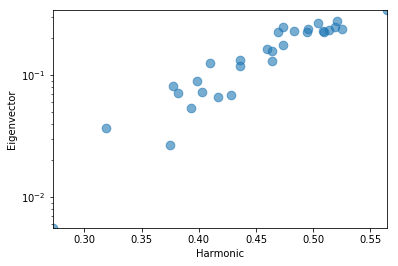

In [36]:
X = 'Harmonic'
Y = 'Eigenvector'
limits = pd.concat(
    [centralities[[X, Y]].min(), centralities[[X, Y]].max()], axis=1
).values
centralities.plot(kind='scatter', 
                  x=X,
                  y=Y, 
                  xlim=limits[0], 
                  ylim=limits[1], 
                  s=75, 
                  logy=True, 
                  alpha=0.6);

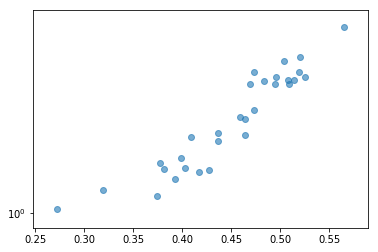

In [42]:
plt.scatter(centralities.Harmonic, centralities.Eigenvector + 1, alpha=0.6);
plt.yscale('log');